In [111]:
import kagglehub
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")

Using Colab cache for faster access to the 'hotel-booking-demand' dataset.


In [112]:
import pandas as pd
import numpy as np

df = pd.read_csv("hotel_bookings.csv")

df_clean = df.copy()

print(df_clean.shape)

(119390, 32)


In [115]:
df_clean[['arrival_date_month','season']].drop_duplicates().sort_values('arrival_date_month')

,arrival_date_month,season
4803,April,Spring
842,August,Summer
3271,December,Winter
3864,February,Winter
3738,January,Winter
0,July,Summer
6275,June,Summer
4275,March,Spring
5521,May,Spring
2835,November,Autumn


In [117]:
print("Shape:", df_clean.shape)

print("\nMissing Values:")
print(df_clean.isnull().sum())

print("\nDuplicates:")
print(df_clean.duplicated().sum())

print("\nData Types:")
print(df_clean.dtypes)

Shape: (119390, 33)

Missing Values:
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent               

In [118]:
duplicate_count = df_clean.duplicated().sum()

print("Duplicates:", duplicate_count)

Duplicates: 31994


In [119]:
df_clean.drop_duplicates(inplace=True)

print(df_clean.shape)

(87396, 33)


In [120]:
df_clean['agent'].isnull().sum()

np.int64(12193)

In [121]:
df_clean['agent'] = df_clean['agent'].fillna(0)

In [122]:
df_clean['country'].isnull().sum()

np.int64(452)

In [123]:
df_clean['country'] = df_clean['country'].fillna(
    df_clean['country'].mode()[0]
)

In [124]:
df_clean['children'].isnull().sum()

np.int64(4)

In [125]:
df_clean['children'] = df_clean['children'].fillna(0)

In [126]:
df_clean.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


###Fix Data Types

In [127]:
df_clean['children'] = df_clean['children'].astype(int)

In [128]:
df_clean['agent'] = df_clean['agent'].astype(int)

In [129]:
df_clean[
    (df_clean['adults'] == 0) &
    (df_clean['children'] == 0) &
    (df_clean['babies'] == 0)
].shape

(166, 33)

In [130]:
df_clean = df_clean[
    ~(
        (df_clean['adults'] == 0) &
        (df_clean['children'] == 0) &
        (df_clean['babies'] == 0)
    )
]

###To Check Average Daily Rate

In [131]:
print(df_clean.columns.tolist())

['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'season']


In [132]:
cat_cols = [
    'hotel',
    'deposit_type',
    'market_segment',
    'customer_type',
    'distribution_channel'
]

df_model = pd.get_dummies(
    df_clean,
    columns=cat_cols,
    drop_first=True
)

In [133]:
print(df_model.shape)

(87230, 45)


In [134]:
df_model.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined
0,0,342,2015,July,27,1,0,0,2,0,...,False,False,False,False,True,False,True,False,False,False
1,0,737,2015,July,27,1,0,0,2,0,...,False,False,False,False,True,False,True,False,False,False
2,0,7,2015,July,27,1,0,1,1,0,...,False,False,False,False,True,False,True,False,False,False
3,0,13,2015,July,27,1,0,1,1,0,...,False,False,False,False,True,False,False,False,False,False
4,0,14,2015,July,27,1,0,2,2,0,...,False,True,False,False,True,False,False,False,True,False


In [135]:
print(df_clean.shape)
print(df_model.shape)

(87230, 33)
(87230, 45)


In [136]:
df_clean['adr'].describe()

,adr
count,87230.000000
mean,106.518031
std,54.891227
min,-6.380000
25%,72.250000
50%,98.200000
75%,134.100000
max,5400.000000


In [137]:
df_clean[df_clean['adr'] < 0].shape

(1, 33)

In [138]:
df_clean[df_clean['adr'] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,season
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,273,NaN,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15,Spring


In [139]:
print(df_clean.shape)

(87230, 33)


In [140]:
df_clean.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [141]:
df_clean.isnull().sum().sum()

np.int64(81993)

In [142]:
df_clean.duplicated().sum()

np.int64(19)

In [143]:
print(df.shape)
print(df_clean.shape)

(119390, 32)
(87230, 33)


In [144]:
df_clean = df_clean[df_clean['adr'] >= 0]

In [145]:
df_clean.drop_duplicates(inplace=True)

print(df_clean.duplicated().sum())

0


In [146]:
df_clean[
    (df_clean['adults']==0) &
    (df_clean['children']==0) &
    (df_clean['babies']==0)
].shape

(0, 33)

In [147]:
df_clean.describe(include='all')

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,season
count,87210,87210.000000,87210.000000,87210.000000,87210,87210.000000,87210.000000,87210.000000,87210.000000,87210.000000,...,87210.000000,5233.000000,87210.000000,87210,87210.000000,87210.000000,87210.000000,87210,87210,87210
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926,4
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2016-02-14,Summer
freq,53274,NaN,NaN,NaN,11242,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,71848,NaN,NaN,NaN,63202,211,29040
mean,NaN,0.275290,79.984233,2016.210320,NaN,26.837060,15.815617,1.004701,2.624137,1.879475,...,81.090081,182.945920,0.746463,NaN,106.527244,0.084325,0.698991,NaN,NaN,NaN
std,NaN,0.446663,86.061487,0.686084,NaN,13.668025,8.835117,1.027403,2.039909,0.621709,...,109.970661,130.457757,10.002141,NaN,54.881284,0.281688,0.832049,NaN,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,6.000000,0.000000,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,0.000000,11.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,9.000000,47.000000,0.000000,NaN,72.250000,0.000000,0.000000,NaN,NaN,NaN
50%,NaN,0.000000,49.000000,2016.000000,NaN,27.000000,16.000000,1.000000,2.000000,2.000000,...,9.000000,169.000000,0.000000,NaN,98.250000,0.000000,0.000000,NaN,NaN,NaN
75%,NaN,1.000000,125.000000,2017.000000,NaN,37.000000,23.000000,2.000000,4.000000,2.000000,...,240.000000,263.000000,0.000000,NaN,134.100000,0.000000,1.000000,NaN,NaN,NaN


In [148]:
df_clean['hotel'].value_counts()

,count
hotel,
City Hotel,53274
Resort Hotel,33936


In [149]:
df_clean['arrival_date'] = pd.to_datetime(
    df_clean['arrival_date_day_of_month'].astype(str)
    + " "
    + df_clean['arrival_date_month']
    + " "
    + df_clean['arrival_date_year'].astype(str),
    errors='coerce'
)

In [150]:
print(
    df_clean['arrival_date'].isnull().sum()
)

0


In [151]:
print("Rows:", df_clean.shape[0])

print("Columns:", df_clean.shape[1])

print("Missing Values:")
print(df_clean.isnull().sum().sum())

print("Duplicates:")
print(df_clean.duplicated().sum())

Rows: 87210
Columns: 34
Missing Values:
81977
Duplicates:
0


In [152]:
df_clean.to_csv(
    "hotel_bookings_cleaned.csv",
    index=False
)

print(
    "Clean dataset saved successfully!"
)

Clean dataset saved successfully!


In [153]:
quality_report = pd.DataFrame({

    'Metric':[
        'Rows',
        'Columns',
        'Missing Values',
        'Duplicate Rows'
    ],

    'Value':[
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum()
    ]
})

display(quality_report)

,Metric,Value
0,Rows,87210
1,Columns,34
2,Missing Values,81977
3,Duplicate Rows,0


In [154]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87210 entries, 0 to 119389
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87210 non-null  object        
 1   is_canceled                     87210 non-null  int64         
 2   lead_time                       87210 non-null  int64         
 3   arrival_date_year               87210 non-null  int64         
 4   arrival_date_month              87210 non-null  object        
 5   arrival_date_week_number        87210 non-null  int64         
 6   arrival_date_day_of_month       87210 non-null  int64         
 7   stays_in_weekend_nights         87210 non-null  int64         
 8   stays_in_week_nights            87210 non-null  int64         
 9   adults                          87210 non-null  int64         
 10  children                        87210 non-null  int64         
 11  babies

###Phase 2: Feature Engineering

In [155]:
df_clean['total_guests'] = (
    df_clean['adults']
    + df_clean['children']
    + df_clean['babies']
)

In [157]:
df_clean['total_nights'] = (
    df_clean['stays_in_weekend_nights']
    + df_clean['stays_in_week_nights']
)

In [158]:
df_clean['estimated_revenue'] = (
    df_clean['adr']
    * df_clean['total_nights']
)

In [159]:
df_clean['is_family'] = np.where(
    (df_clean['children'] > 0) |
    (df_clean['babies'] > 0),
    1,
    0
)

In [160]:
df_clean['guest_type'] = np.where(
    df_clean['is_repeated_guest'] == 1,
    'Repeat',
    'New'
)

In [161]:
summer = ['June','July','August']
winter = ['December','January','February']
monsoon = ['July','August','September']

def get_season(month):

    if month in summer:
        return 'Summer'

    elif month in winter:
        return 'Winter'

    else:
        return 'Other'

df_clean['season'] = (
    df_clean['arrival_date_month']
    .apply(get_season)
)

In [162]:
df_clean['lead_time_group'] = pd.cut(
    df_clean['lead_time'],
    bins=[0,30,90,180,1000],
    labels=[
        'Last Minute',
        'Short Term',
        'Medium Term',
        'Long Term'
    ]
)

In [163]:
df_clean.to_csv(
    'hotel_bookings_featured.csv',
    index=False
)

In [164]:
df_clean[['total_guests',
          'total_nights',
          'estimated_revenue',
          'is_family',
          'guest_type',
          'season',
          'lead_time_group']].head()

,total_guests,total_nights,estimated_revenue,is_family,guest_type,season,lead_time_group
0,2,0,0.0,0,New,Summer,Long Term
1,2,0,0.0,0,New,Summer,Long Term
2,1,1,75.0,0,New,Summer,Last Minute
3,1,1,75.0,0,New,Summer,Last Minute
4,2,2,196.0,0,New,Summer,Last Minute


In [165]:
df_clean[['total_guests',
          'total_nights',
          'estimated_revenue']].describe()

,total_guests,total_nights,estimated_revenue
count,87210.000000,87210.000000,87210.000000
mean,2.029251,3.628838,395.006999
std,0.790140,2.742996,369.449515
min,1.000000,0.000000,0.000000
25%,2.000000,2.000000,153.000000
50%,2.000000,3.000000,299.200000
75%,2.000000,5.000000,504.000000
max,55.000000,69.000000,7590.000000


In [166]:
cancel_rate = (
    df_clean['is_canceled']
    .value_counts(normalize=True)
    * 100
)

print(cancel_rate)

is_canceled
0    72.471047
1    27.528953
Name: proportion, dtype: float64


In [167]:
lost_revenue = (
    df_clean[df_clean['is_canceled']==1]
    ['estimated_revenue']
    .sum()
)

print(lost_revenue)

11483802.98


In [168]:
earned_revenue = (
    df_clean[df_clean['is_canceled']==0]
    ['estimated_revenue']
    .sum()
)

print(earned_revenue)

22964757.390000004


In [169]:
pd.crosstab(
    df_clean['is_family'],
    df_clean['is_canceled'],
    normalize='index'
)*100

is_canceled,0,1
is_family,,
0,73.254638,26.745362
1,65.747556,34.252444


In [170]:
pd.crosstab(
    df_clean['guest_type'],
    df_clean['is_canceled'],
    normalize='index'
)*100

is_canceled,0,1
guest_type,,
New,71.676983,28.323017
Repeat,92.268808,7.731192


In [171]:
pd.crosstab(
    df_clean['lead_time_group'],
    df_clean['is_canceled'],
    normalize='index'
)*100

is_canceled,0,1
lead_time_group,,
Last Minute,81.368609,18.631391
Short Term,67.957917,32.042083
Medium Term,64.991220,35.008780
Long Term,60.258591,39.741409


In [172]:
month_bookings = (
    df_clean['arrival_date_month']
    .value_counts()
)

print(month_bookings)

arrival_date_month
August       11242
July         10042
May           8344
April         7897
June          7756
March         7485
October       6919
September     6682
February      6077
December      5110
November      4973
January       4683
Name: count, dtype: int64


In [173]:
monthly_revenue = (
    df_clean.groupby(
        'arrival_date_month'
    )['estimated_revenue']
    .sum()
    .sort_values(
        ascending=False
    )
)

display(monthly_revenue)

,estimated_revenue
arrival_date_month,
August,7238982.39
July,5861022.26
June,3495592.65
May,3122247.78
April,2785987.13
September,2688490.85
March,2048068.89
October,2032533.25
February,1472398.43


In [174]:
pd.crosstab(
    df_clean['customer_type'],
    df_clean['is_canceled'],
    normalize='index'
)*100

is_canceled,0,1
customer_type,,
Contract,83.668262,16.331738
Group,90.203327,9.796673
Transient,69.853023,30.146977
Transient-Party,84.742427,15.257573


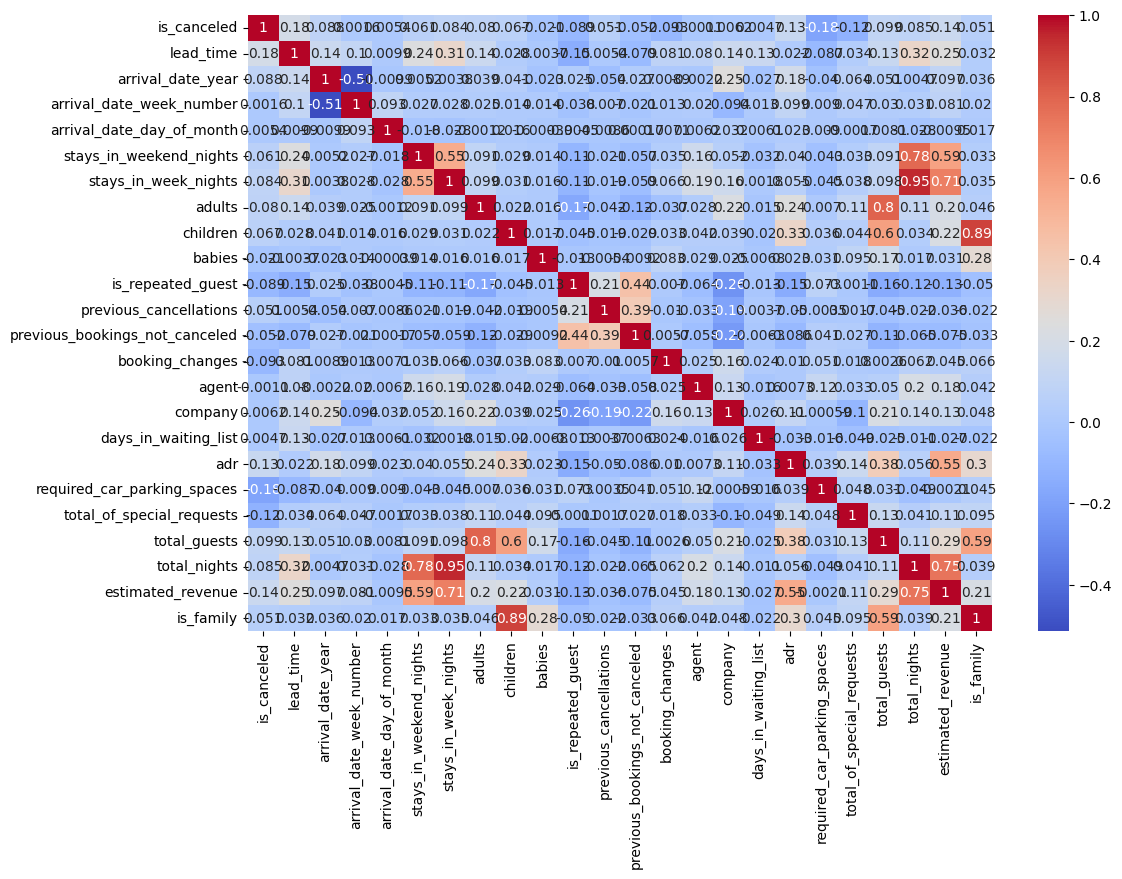

In [175]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df_clean.select_dtypes(
        include=np.number
    ).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

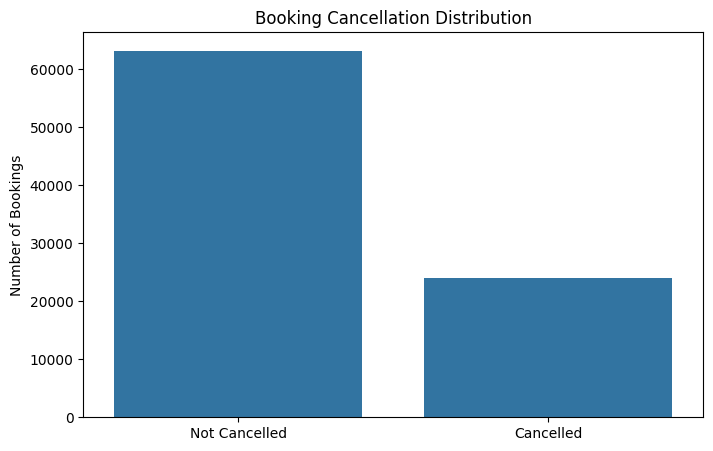

In [176]:
import matplotlib.pyplot as plt
import seaborn as sns

cancel_data = (
    df_clean['is_canceled']
    .value_counts()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=['Not Cancelled','Cancelled'],
    y=cancel_data.values
)

plt.title('Booking Cancellation Distribution')
plt.ylabel('Number of Bookings')

plt.show()

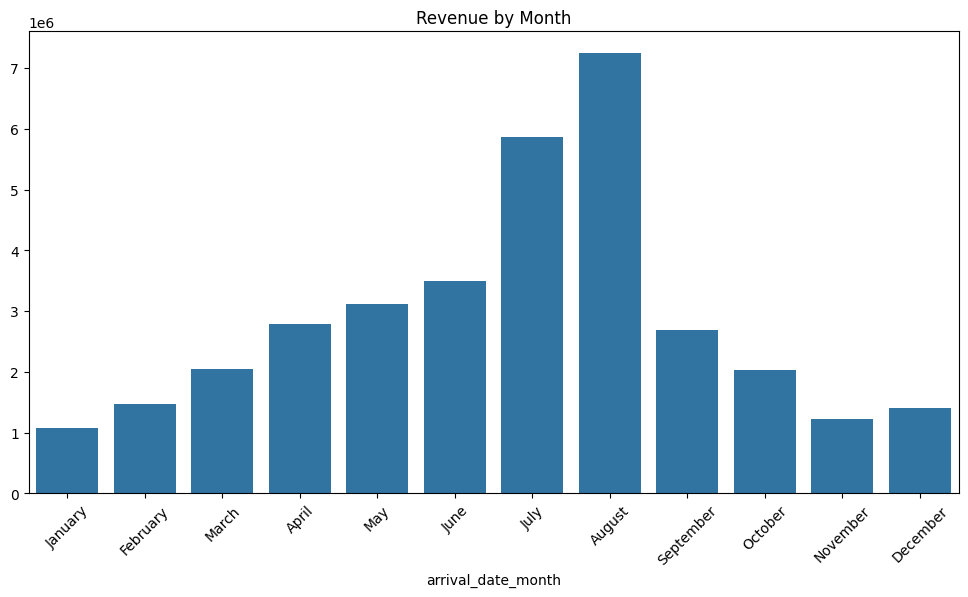

In [177]:
monthly_revenue = (
    df_clean.groupby('arrival_date_month')
    ['estimated_revenue']
    .sum()
)

month_order = [
    'January','February','March',
    'April','May','June',
    'July','August','September',
    'October','November','December'
]

monthly_revenue = (
    monthly_revenue
    .reindex(month_order)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=monthly_revenue.index,
    y=monthly_revenue.values
)

plt.xticks(rotation=45)

plt.title('Revenue by Month')

plt.show()

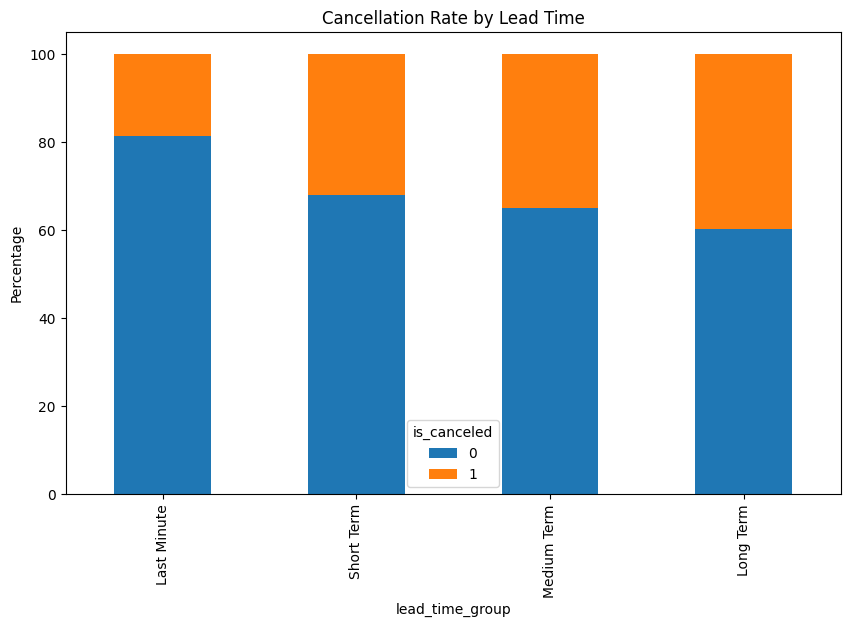

In [178]:
lead_cancel = pd.crosstab(
    df_clean['lead_time_group'],
    df_clean['is_canceled'],
    normalize='index'
)*100

lead_cancel.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title(
    'Cancellation Rate by Lead Time'
)

plt.ylabel('Percentage')

plt.show()

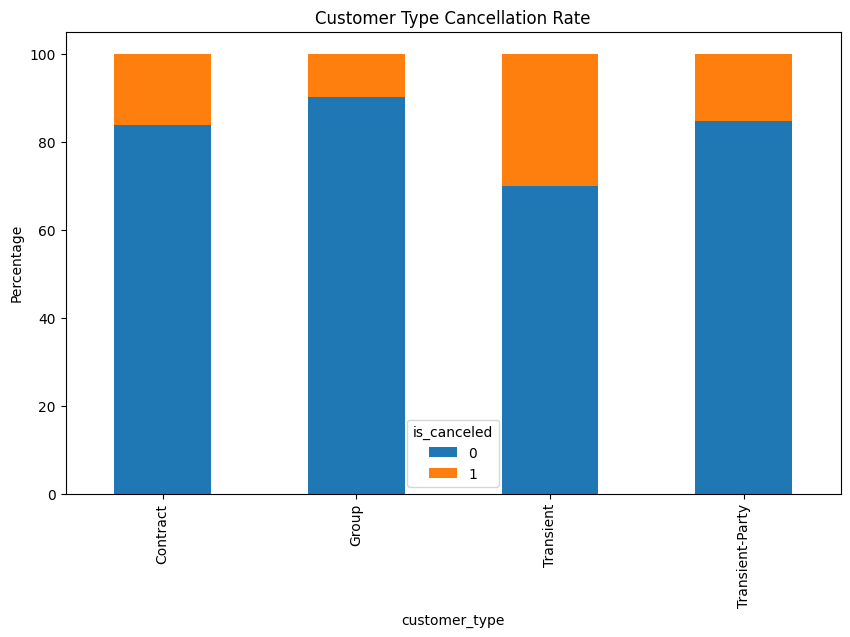

In [179]:
customer_cancel = (
    pd.crosstab(
        df_clean['customer_type'],
        df_clean['is_canceled'],
        normalize='index'
    )*100
)

customer_cancel.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title(
    'Customer Type Cancellation Rate'
)

plt.ylabel('Percentage')

plt.show()

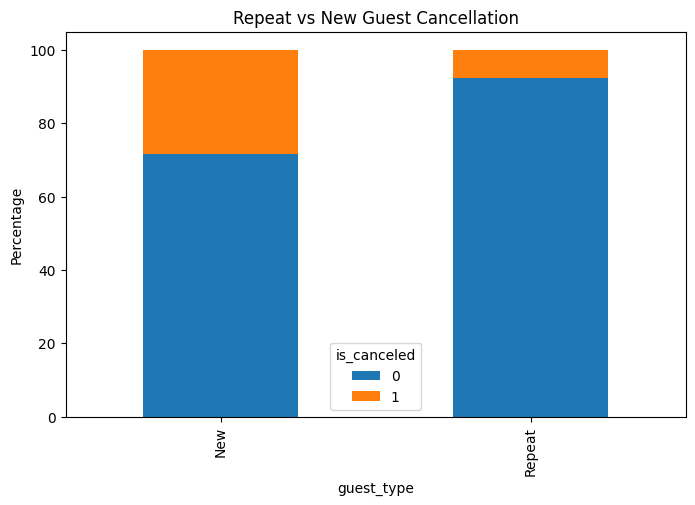

In [180]:
repeat_cancel = (
    pd.crosstab(
        df_clean['guest_type'],
        df_clean['is_canceled'],
        normalize='index'
    )*100
)

repeat_cancel.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title(
    'Repeat vs New Guest Cancellation'
)

plt.ylabel('Percentage')

plt.show()

###Machine Learning

In [181]:
extra_features = [
    'lead_time',
    'adr',
    'total_guests',
    'total_nights',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests',

    # NEW
    'is_repeated_guest'
]

In [182]:
print('total_guests' in df_clean.columns)
print('total_nights' in df_clean.columns)

print('total_guests' in df_model.columns)
print('total_nights' in df_model.columns)

True
True
False
False


In [183]:
cat_cols = [
    'hotel',
    'deposit_type',
    'market_segment',
    'customer_type',
    'distribution_channel'
]

df_model = pd.get_dummies(
    df_clean,
    columns=cat_cols,
    drop_first=True
)

In [184]:
print('total_guests' in df_model.columns)
print('total_nights' in df_model.columns)

True
True


In [185]:
num_features = [
    'lead_time',
    'adr',
    'total_guests',
    'total_nights',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'total_of_special_requests',
    'is_repeated_guest',
    'required_car_parking_spaces'
]

encoded_features = [
    c for c in df_model.columns
    if any(c.startswith(p) for p in cat_cols)
]

features = num_features + encoded_features

X = df_model[features]
y = df_model['is_canceled']

print("Feature count:", len(features))
print(y.value_counts(normalize=True).round(3))

Feature count: 28
is_canceled
0    0.725
1    0.275
Name: proportion, dtype: float64


In [186]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(69768, 28)
(17442, 28)


In [187]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [188]:
y_pred = model.predict(X_test)

In [189]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(
    accuracy_score(
        y_test,
        y_pred
    )
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

0.7847150556128885
              precision    recall  f1-score   support

           0       0.80      0.94      0.86     12640
           1       0.70      0.39      0.50      4802

    accuracy                           0.78     17442
   macro avg       0.75      0.66      0.68     17442
weighted avg       0.77      0.78      0.76     17442



In [190]:
importance = pd.DataFrame({

    'Feature': features,

    'Coefficient':
    model.coef_[0]

})

importance.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
12,deposit_type_Non Refund,3.601257
4,previous_cancellations,1.685949
22,customer_type_Transient,0.771205
19,market_segment_Online TA,0.277439
14,market_segment_Complementary,0.260221
13,deposit_type_Refundable,0.153690
26,distribution_channel_TA/TO,0.149421
27,distribution_channel_Undefined,0.095408
23,customer_type_Transient-Party,0.087608
2,total_guests,0.078163


In [191]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [192]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(
    accuracy_score(
        y_test,
        rf_pred
    )
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

0.7909643389519551
              precision    recall  f1-score   support

           0       0.83      0.89      0.86     12640
           1       0.64      0.54      0.59      4802

    accuracy                           0.79     17442
   macro avg       0.74      0.71      0.72     17442
weighted avg       0.78      0.79      0.78     17442



In [193]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [194]:
rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [195]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

print("\n")

print(classification_report(
    y_test,
    rf_pred
))

Accuracy : 0.7907350074532737
Precision: 0.6445057701956849
Recall   : 0.5349854227405247
F1 Score : 0.5846609012289485


              precision    recall  f1-score   support

           0       0.83      0.89      0.86     12640
           1       0.64      0.53      0.58      4802

    accuracy                           0.79     17442
   macro avg       0.74      0.71      0.72     17442
weighted avg       0.78      0.79      0.78     17442



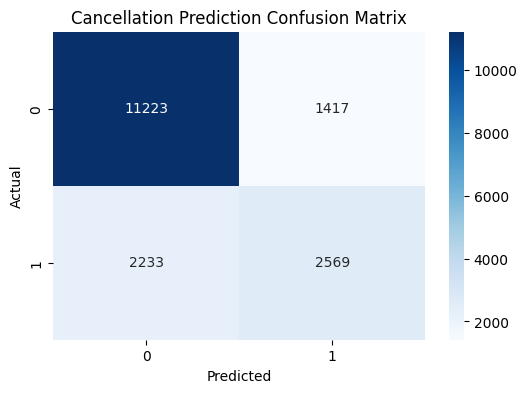

In [196]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Cancellation Prediction Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [197]:
importance = pd.DataFrame({

    'Feature': features,

    'Importance': rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(
    importance.head(15)
)

                          Feature  Importance
0                       lead_time    0.320487
1                             adr    0.292052
3                    total_nights    0.083963
8       total_of_special_requests    0.064040
19       market_segment_Online TA    0.031706
10    required_car_parking_spaces    0.031348
2                    total_guests    0.028340
4          previous_cancellations    0.023499
6                 booking_changes    0.022492
12        deposit_type_Non Refund    0.021956
22        customer_type_Transient    0.014377
18   market_segment_Offline TA/TO    0.013546
11             hotel_Resort Hotel    0.012238
23  customer_type_Transient-Party    0.008402
26     distribution_channel_TA/TO    0.008265


<Figure size 1000x600 with 0 Axes>

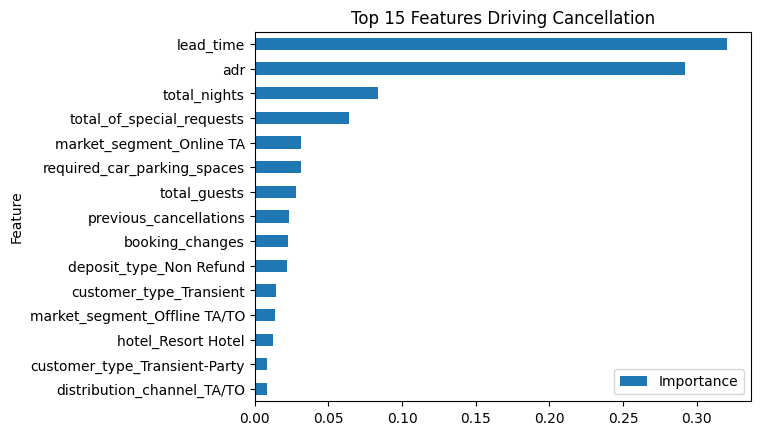

In [198]:
plt.figure(figsize=(10,6))

importance.head(15).sort_values(
    by='Importance'
).plot(
    x='Feature',
    y='Importance',
    kind='barh'
)

plt.title(
    'Top 15 Features Driving Cancellation'
)

plt.show()

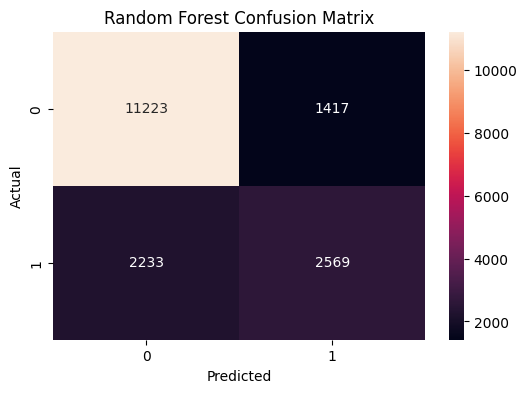

In [199]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [200]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                           Feature  Importance
0                        lead_time    0.320487
1                              adr    0.292052
3                     total_nights    0.083963
8        total_of_special_requests    0.064040
19        market_segment_Online TA    0.031706
10     required_car_parking_spaces    0.031348
2                     total_guests    0.028340
4           previous_cancellations    0.023499
6                  booking_changes    0.022492
12         deposit_type_Non Refund    0.021956
22         customer_type_Transient    0.014377
18    market_segment_Offline TA/TO    0.013546
11              hotel_Resort Hotel    0.012238
23   customer_type_Transient-Party    0.008402
26      distribution_channel_TA/TO    0.008265
5   previous_bookings_not_canceled    0.005070
24     distribution_channel_Direct    0.003798
17           market_segment_Groups    0.002780
16           market_segment_Direct    0.002649
9                is_repeated_guest    0.002551
7            

In [209]:
import joblib

joblib.dump(rf, "hotel_cancellation_model.pkl")

['hotel_cancellation_model.pkl']

In [202]:
df_clean.to_csv(
    "hotel_bookings_cleaned.csv",
    index=False
)

In [203]:
print("Feature count:", len(features))
print(y.value_counts(normalize=True).round(3))

Feature count: 28
is_canceled
0    0.725
1    0.275
Name: proportion, dtype: float64


In [206]:
season_map = {
    'December':'Winter',
    'January':'Winter',
    'February':'Winter',

    'March':'Spring',
    'April':'Spring',
    'May':'Spring',

    'June':'Summer',
    'July':'Summer',
    'August':'Summer',

    'September':'Autumn',
    'October':'Autumn',
    'November':'Autumn'
}

df_clean['season'] = df_clean['arrival_date_month'].map(season_map)
df_clean['season'].value_counts()

,count
season,
Summer,29040
Spring,23726
Autumn,18574
Winter,15870


In [207]:
season_map = {
    'December':'Winter',
    'January':'Winter',
    'February':'Winter',

    'March':'Spring',
    'April':'Spring',
    'May':'Spring',

    'June':'Summer',
    'July':'Summer',
    'August':'Summer',

    'September':'Autumn',
    'October':'Autumn',
    'November':'Autumn'
}

df_clean['season'] = df_clean['arrival_date_month'].map(season_map)

In [208]:
df_clean['season'].value_counts()


,count
season,
Summer,29040
Spring,23726
Autumn,18574
Winter,15870
